# Generating Points on the Flag Manifold using Polynomial Kernels

## Setup

In [1]:
import rmatqmcpy 
import torch
torch.set_default_dtype(torch.float64)
import numpy as np 
import qmcpy as qp
import agsutil
import time
import pandas as pd
import os
import matplotlib
from matplotlib import pyplot
MPLP = agsutil.mpl_setup()
agsutil.print_data_signatures(MPLP,"MPLP",verbose_indent=0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch device = %s"%DEVICE)

MPLP['PW'] = 30
MPLP['FS'] = 30
MPLP['COLORS'] a list of length 10
MPLP['LINESTYLES'] a list of length 10
MPLP['MARKERS'] a list of length 12
torch device = cuda


## Kernel Setup

In [ ]:
def compute_tau_int_traceXY_topow_r(delta, r):
    r""" 
    Compute the expected value of the trace of the product of two random flag matrices raised to the power `r`.

    Args:
        delta (torch.Tensor): Eigenvalues of the flag matrices.
        r (int): The power to which the trace is raised.

    Returns:
        tau (torch.Tensor): A tensor of shape `(r+1,)` containing the expected values for powers `0` to `r`.

    Examples:
        >>> torch.set_default_dtype(torch.float64) 

        >>> delta = torch.arange(1,4,dtype=float)
        >>> delta = delta/torch.linalg.norm(delta)
        >>> tau = compute_tau_int_traceXY_topow_r(delta,2)
        >>> tau 
        tensor([1.0000, 0.8571, 0.7388])

        >>> n = delta.size(-1) 
        >>> T1 = delta.sum()**2
        >>> T2 = (delta**2).sum()
        >>> tauref = torch.tensor([1,T1/n,1/((n-1)*n*(n+2))*((n+1)*T1**2+2*n*T2**2-4*T1*T2)]) 
        >>> tauref
        tensor([1.0000, 0.8571, 0.7388])
        >>> torch.allclose(tau,tauref)
        True

        >>> compute_tau_int_traceXY_topow_r(delta,3)
        tensor([1.0000, 0.8571, 0.7388, 0.6402])
    """
    import sympy
    try:
        from jackpy.jack import ZonalPol
    except ImportError:
        raise ImportError("jackpy not found, try pip install jackpolynomials or pip install --ignore-requires-python jackpolynomials")
    n = delta.size(-1)
    assert delta.shape==(n,)
    device = delta.device
    tau = torch.zeros(r+1,device=device)
    tau[0] = 1
    lamlist = delta.cpu().tolist()
    onesN = [1.]*n
    for t in range(1,r+1):
        for m in agsutil.enumerate_partitions(t):
            if len(m)>n: continue
            mpart = sympy.combinatorics.partitions.IntegerPartition(m)
            zp = ZonalPol(n,mpart)
            exprtm = (zp(*lamlist)**2)/zp(*onesN)
            tau[t] += float(exprtm)
    return tau
tau = compute_tau_int_traceXY_topow_r(delta,r)
jvec = torch.arange(r+1,device=device)
rt = jvec[-1]
double_integral = (agsutil.comb(rt,jvec)*c**(rt-jvec)*tau).sum()

In [2]:
delta = torch.arange(1,4,device=DEVICE,dtype=float)
delta = delta/torch.linalg.norm(delta)
kernel = rmatqmcpy.KernelPolyFlag(delta,r=8,c=1)
print("kernel.tau = %s"%kernel.tau)
print("kernel.double_integral = %s"%kernel.double_integral)

kernel.tau = tensor([1.0000, 0.8571, 0.7388, 0.6402, 0.5578, 0.4885, 0.4300, 0.3804, 0.3380],
       device='cuda:0')
kernel.double_integral = tensor(146.2206, device='cuda:0')


## Transform and Generators

In [3]:
def opt_weights(x, eps=1e-12):
    kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:]) # (...,n,n)
    b = torch.ones(kmat.size(-1),device=DEVICE) # (...,n,)
    L = torch.linalg.cholesky(kmat+eps*torch.eye(kmat.size(-1),device=DEVICE),upper=False) # (...,n,n)
    w = torch.cholesky_solve(b[...,None],L,upper=False)[...,0] # (...,n)
    return w
def genflag_qr_iid_x_opt_w(n, delta, seed=None):
    x = rmatqmcpy.genflag_x_qr_iid(n,delta,seed)
    w = opt_weights(x)
    return x,w
def genflag_qr_ld_x_opt_w(n, delta, seed=None):
    x = rmatqmcpy.genflag_x_qr_ld(n,delta,seed)
    w = opt_weights(x)
    return x,w
def genflag_eig_iid_x_opt_w(n, delta, seed=None):
    x = rmatqmcpy.genflag_x_eig_iid(n,delta,seed)
    w = opt_weights(x)
    return x,w
def genflag_eig_ld_x_opt_w(n, delta, seed=None):
    x = rmatqmcpy.genflag_x_eig_ld(n,delta,seed)
    w = opt_weights(x)
    return x,w

## Optimized Points and Weights

In [4]:
def genflag_opt_x_w(
        n,
        delta,
        seed=None,
        verbose = False, 
        iters = 100,
        eps_kmat = 1e-8,
        verbose_indent = 4,
        ):
    t = delta.size(-1)
    u = torch.from_numpy(qp.DigitalNetB2(t**2,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE)
    theta0 = rmatqmcpy.tff_qr(u)
    zerosn = torch.zeros(n,device=DEVICE)
    onesn = torch.ones(n,device=DEVICE)
    eyen = torch.eye(n,device=DEVICE)
    def discrepancy_loss(theta):
        q = agsutil.to_unitary_qr(theta)
        x = torch.einsum("...ij,...j,...kj->...ik",q,delta,q)
        kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:]) # (n,n)
        L = torch.linalg.cholesky(kmat+eps_kmat*eyen,upper=False) # (n,n)
        v = torch.linalg.solve_triangular(L,onesn[...,None],upper=False)[...,0]
        # discrep = 1-(v**2).sum(-1)
        return v,x,L
    u,x,L = agsutil.lm_opt(
        f = discrepancy_loss,
        theta0 = theta0,
        ytrue = zerosn,
        iters = iters,
        verbose = verbose,
        verbose_indent = verbose_indent,
        loss_mult = -1,
        loss_shift = 1,
        # store_data_iters = True,
    )
    # print(data["losses_quantiles"]["50"])
    # print(data["losses_quantiles"]["50"][1:]-data["losses_quantiles"]["50"][:-1])
    w = torch.cholesky_solve(onesn[...,None],L,upper=False)[...,0]
    return x,w

genflag_opt_x_w(
    n = 2**3, 
    delta=delta,
    seed = 17,
    verbose = None);

    iter i     | losses_quantiles                                          | lams_quantiles                                            | alphas_quantiles                                          | times     
               | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        |           
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    0          | 6.5e-02   | 6.5e-02   | 6.5e-02   | 6.5e-02   | 6.5e-02   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 0.4        
    5          | 2.4e-02   | 2.4e-02   | 2.4e-02   | 2.4e-02   | 2.4e-02   | 3.2e-05   | 3.2e-05   | 3.2e-05   | 3.2e-05   | 3.2e-05   | 6.2e-02   | 6.2e-02   | 6.2e-0

## Convergence on a Test Function

In [5]:
def discrepancy(x, w, return_kmat=False):
    assert x.ndim>=2
    assert x.size(-3)==w.size(-1)
    kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:]) # (...,n,n)
    discrep = torch.einsum("...i,...ij,...j->...",w,kmat,w)-2*w.sum()+1 # (...,)
    if return_kmat:
        return discrep,kmat 
    else:
        return discrep

In [6]:
genf_funcs = [
    [r"QR IID $x$ ~ Equal $w$", rmatqmcpy.genflag_x_qr_iid_equal_w], 
    [r"QR LD $x$ ~ Equal $w$", rmatqmcpy.genflag_x_qr_ld_equal_w], 
    [r"QR IID $x$ ~ Opt $w$", genflag_qr_iid_x_opt_w], 
    [r"QR LD $x$ ~ Opt $w$", genflag_qr_ld_x_opt_w], 
    [r"Eig IID $x$ ~ Equal $w$", rmatqmcpy.genflag_x_eig_iid_equal_w], 
    [r"Eig LD $x$ ~ Equal $w$", rmatqmcpy.genflag_x_eig_ld_equal_w], 
    [r"Eig IID $x$ ~ Opt $w$", genflag_eig_iid_x_opt_w], 
    [r"Eig LD $x$ ~ Opt $w$", genflag_eig_ld_x_opt_w], 
    [r"Opt $x$ ~ Opt $w$", genflag_opt_x_w], 
    
]
n = 2**torch.arange(2,8)
trials = 5
seeds = [i for i in range(trials)]
discreps = torch.empty((len(genf_funcs),len(n),trials))
t0 = time.perf_counter()
cond = np.nan
for i,(key,genf_func) in enumerate(genf_funcs):
    print(key)
    for j in range(len(n)):
        print("    n = %d"%n[j])
        for t in range(trials):
            x,w = genf_func(n=n[j],delta=delta,seed=seeds[t])
            discreps[i,j,t] = float(discrepancy(x,w).cpu())
            # cond = torch.linalg.cond(kernel(x[...,:,None,:,:],x[...,None,:,:,:],delta,r,c)+1e-8*torch.eye(n[j],device=DEVICE))
            print("        trial %-10d time %-10.1f discrep %-10.1e Kmat_cond %-10.1e"%(t,time.perf_counter()-t0,discreps[i,j,t],cond))

QR IID $x$ ~ Equal $w$
    n = 4
        trial 0          time 0.0        discrep 9.4e-02    Kmat_cond nan       
        trial 1          time 0.0        discrep 3.9e-01    Kmat_cond nan       
        trial 2          time 0.0        discrep 1.9e-01    Kmat_cond nan       
        trial 3          time 0.0        discrep 7.6e-02    Kmat_cond nan       
        trial 4          time 0.0        discrep 1.7e-01    Kmat_cond nan       
    n = 8
        trial 0          time 0.0        discrep 7.4e-02    Kmat_cond nan       
        trial 1          time 0.0        discrep 1.5e-01    Kmat_cond nan       
        trial 2          time 0.0        discrep 5.4e-02    Kmat_cond nan       
        trial 3          time 0.0        discrep 3.8e-02    Kmat_cond nan       
        trial 4          time 0.0        discrep 7.9e-02    Kmat_cond nan       
    n = 16
        trial 0          time 0.0        discrep 2.2e-02    Kmat_cond nan       
        trial 1          time 0.0        discrep 7.1e-0

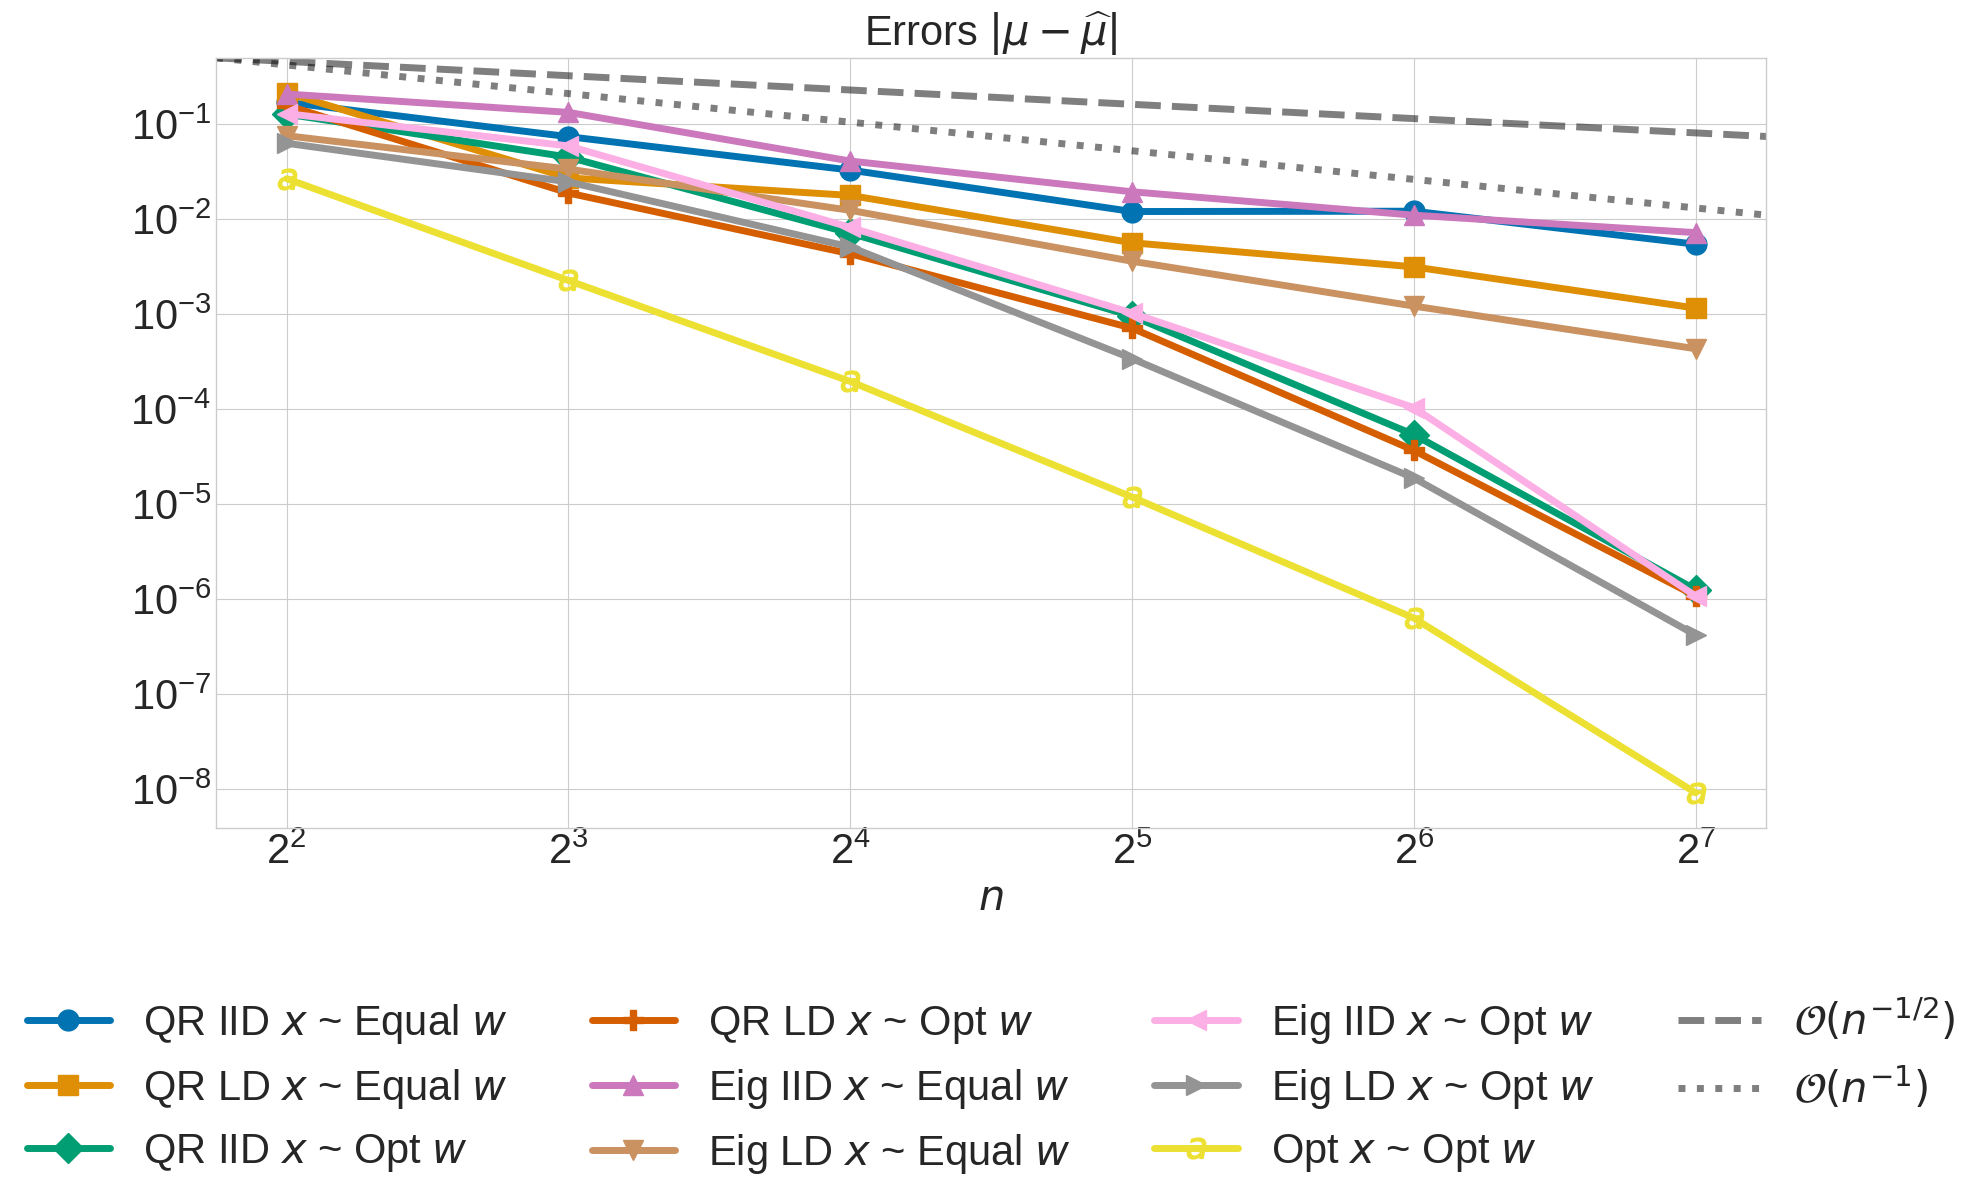

In [7]:
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(MPLP["PW"]/1.5,MPLP["PW"]/2/1.5),sharex=True,sharey=False)
for i,(key,_) in enumerate(genf_funcs):
    ax.plot(n,discreps[i].median(-1).values,color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i],label=key)
ax.set_yscale("log",base=10)
ax.set_xscale("log",base=2)
xmin,xmax = ax.get_xlim()
ymin,ymax = ax.get_ylim()
ax.set_xlim([xmin,xmax])
ax.set_ylim([ymin,ymax])
ax.axline([xmin,ymax],[2*xmin,2**(-1/2)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(n^{-1/2})$",linestyle="dashed")
ax.axline([xmin,ymax],[2*xmin,2**(-1)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(n^{-1})$",linestyle="dotted")
ax.legend(frameon=False,ncols=4,loc="lower center",bbox_to_anchor=(.5,-.5))
ax.set_title(r"Errors $|\mu - \widehat{\mu}|$")
ax.set_xlabel(r"$n$");

In [8]:
discreps_df = pd.DataFrame(discreps.median(-1).values.T,columns=[name for (name,_) in genf_funcs])
discreps_df['n'] = n
discreps_df.set_index('n')
print(r"Discrep")
discreps_df


Discrep


,QR IID $x$ ~ Equal $w$,QR LD $x$ ~ Equal $w$,QR IID $x$ ~ Opt $w$,QR LD $x$ ~ Opt $w$,Eig IID $x$ ~ Equal $w$,Eig LD $x$ ~ Equal $w$,Eig IID $x$ ~ Opt $w$,Eig LD $x$ ~ Opt $w$,Opt $x$ ~ Opt $w$,n
0,0.169263,0.212884,0.127193,0.157258,0.206905,0.075349,0.128532,6.269931e-02,2.658226e-02,4
1,0.073591,0.027102,0.044832,0.018779,0.132595,0.033504,0.058810,2.458480e-02,2.253423e-03,8
2,0.032756,0.017727,0.007086,0.004302,0.040754,0.012339,0.008161,5.073947e-03,1.950536e-04,16
3,0.011990,0.005624,0.000951,0.000710,0.019347,0.003593,0.001024,3.389741e-04,1.182937e-05,32
4,0.012083,0.003135,0.000054,0.000037,0.010974,0.001212,0.000103,1.877018e-05,6.298549e-07,64
5,0.005429,0.001154,0.000001,0.000001,0.007187,0.000431,0.000001,4.173193e-07,9.123158e-09,128
